# 5. POŁĄCZENIA RESIDUALNE I TRANSFER LEARNING

## 0.Cel listy

Celem tej listy zadań jest zapoznanie się z:

* gotowymi architekturami sieci neuronowych,
* ideą **połączeń residualnych (skip connections)**,
* oraz praktycznym wykorzystaniem **transfer learningu** w zadaniach z zakresu wizji komputerowej.

W poprzednich listach budowaliśmy sieci neuronowe „od zera”, projektując architekturę warstwa po warstwie. W praktyce jednak **bardzo rzadko trenuje się modele od podstaw**- zamiast tego korzysta się z gotowych, sprawdzonych architektur i wag wytrenowanych na dużych zbiorach danych, dotrenowując model pod konretne zadanie.



W tej liście:

* skupimy się na architekturach z rodziny **ResNet**,
* zobaczymy, czym są i po co stosuje się połączenia residualne,
* porównamy różne strategie treningu:

  * inferencję na modelu pretrenowanym,
  * trenowanie tylko ostatniej warstwy,
  * fine-tuning całego modelu,
  * trening od zera.



Do wykonania zadania rekomendowane jest użycie zbioru **CIFAR** z torchvision z powodu, że jest to trudniejszy zbiór i powinno być na nim lepiej widać, różne schematy uczenia, ale jeśli będzie występowal problem z zasobami obliczeniowymi można wykonać zadanie na zbiorze **FashionMNIST**




## 1.Połączenia residualne- teoria

### Problem zanikającego i wybuchającego gradientu

Podczas trenowania sieci neuronowej używamy algorytmu **propagacji wstecznej (backpropagation)**, w którym gradient funkcji straty jest przekazywany od wyjścia sieci do jej początkowych warstw.

Dla bardzo głębokich sieci pojawiają się dwa poważne problemy:

###  Zanikający gradient (vanishing gradient)

* gradient w kolejnych warstwach staje się coraz mniejszy,
* pierwsze warstwy uczą się bardzo wolno lub wcale,
* sieć nie wykorzystuje swojej głębokości.

###  Wybuchający gradient (exploding gradient)

* gradient w kolejnych warstwach gwałtownie rośnie,
* prowadzi to do niestabilnego treningu,
* wagi mogą przyjmować bardzo duże wartości (NaN).

Oba problemy są szczególnie widoczne w **głębokich sieciach** (dziesiątki lub setki warstw).



## Skąd bierze się ten problem? (intuicyczna matematyka)

Rozważmy bardzo uproszczony przypadek sieci składającej się z wielu warstw:

$$
h_l = f(W_l h_{l-1})
$$


Podczas propagacji wstecznej gradient względem wcześniejszych warstw zawiera **iloczyn pochodnych**:

$$
\frac{\partial L}{\partial h_0}
$$

$$
\frac{\partial L}{\partial h_L}
\cdot
\prod_{l=1}^{L}
\frac{\partial h_l}{\partial h_{l-1}}
$$

Jeśli:

* pochodne są **mniejsze od 1** - iloczyn dąży do zera → *zanik gradientu*
* pochodne są **większe od 1** - iloczyn rośnie wykładniczo → *wybuch gradientu*

Nawet przy użyciu funkcji aktywacji takich jak ReLU oraz technik typu Batch Normalization, problem **nie znika całkowicie** dla bardzo głębokich sieci.

#### Dodatkowe materiały:
- [Vanishing AND Exploding Gradient Problem Explained](https://www.youtube.com/watch?v=CzNFuL_5uig)
- [kod + wizaulizacje problemu](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/)




### Intuicja stojąca za połączeniem residualnym

Zastanówmy się nad prostym przypadkiem.

Załóżmy, że idealna transformacja pomiędzy wejściem a wyjściem pewnej części sieci to:
$$
H(x) = x
$$

Czyli: **warstwy nic nie zmieniają**.

Dla klasycznej sieci neuronowej oznacza to, że musi ona nauczyć się funkcji identyczności, co w praktyce **nie jest trywialne** dla wielu warstw nieliniowych.



Zamiast uczyć się funkcji:
$$
H(x)
$$

możemy uczyć się **residuum**:
$$
F(x) = H(x) - x
$$

Jeśli najlepszym rozwiązaniem jest identyczność, to:
$$
F(x) = 0
$$

Uczenie się „zera” lub „małej poprawki” jest:

* łatwiejsze,
* stabilniejsze,
* szybsze dla optymalizacji gradientowej.



### Wzór matematyczny połączenia residualnego

Połączenie residualne definiujemy jako:

$$
y = F(x) + x
$$

gdzie:

* x - wejście do bloku,
* F(x) - klasyczna transformacja (np. Conv -> ReLU -> Conv),
* y - wyjście bloku residualnego.

### Co to zmienia?

* gradient może przepływać **bezpośrednio** przez składnik (+x),
* nawet jeśli F(x) jest trudne do nauczenia,
* sieć zawsze ma „bezpieczną ścieżkę” dla propagacji gradientu.


## Najważniejsze konsekwencje połączeń residualnych

* umożliwiają trenowanie **bardzo głębokich sieci**,
* zmniejszają problem degradacji jakości,
* stabilizują propagację gradientu,
* sprawiają, że dodawanie kolejnych warstw **nie pogarsza wyników**.

Poniżej obrazek przedstawiający schemat działania tego połączenia.


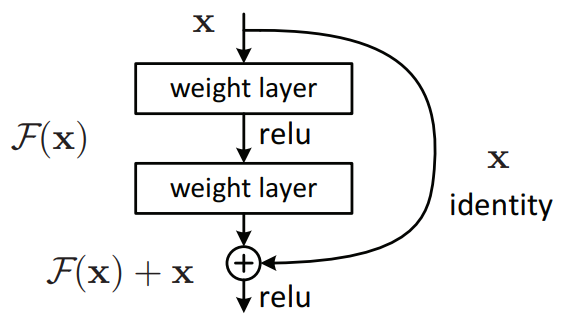

DODATKOWE MATERIAŁY:
- [ORGINALNY PAPER](https://arxiv.org/pdf/1512.03385) - Gorąco polecam, ponieważ autorzy bardzo klarownie postawili hipotezę, ekperyment weryfikujący, oraz wnioski. Jest to wzór pod względem tego jak publikacja powinna wyglądać.
- [ORGINALNY PAPER OMÓWIENIE NA YT](https://www.youtube.com/watch?v=GWt6Fu05voI)
- [SZCZEGÓŁOWE WYJAŚNIENIE](https://mbrenndoerfer.com/writing/residual-connections-deep-neural-networks-resnet)

## 2. ZADANIE 1. IMPLEMENTACJA MODUŁU RESIDUALNEGO
Jako zadanie rozgrzewkowe należy na podstawie schematu powyżej dokończyć implementację modułu residualnego, przepuścić przez niego "dummy input" i uruchomić testy w celu weryfikacji poprawności. Celem jest zobaczenie przykładowej implementacji takiego bloku.

**UWAGA**: Symbol "+" na schemacie odpowada zwykłemu **dodaniu tensorów** a nie konkatenacji.

In [2]:
#Dummy wejście (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

import torch
# Ustalmy powtarzalność
torch.manual_seed(0)

# Dummy batch obrazów: (batch_size, channels, height, width)
B, C, H, W = 4, 16, 32, 32
x = torch.randn(B, C, H, W)
print("x shape:", x.shape)


x shape: torch.Size([4, 16, 32, 32])


In [3]:
# Moduł ResidualBlock z brakującym kodem (TODO)

import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    Blok residualny zgodny ze schematem:
        x -> Conv -> ReLU -> Conv -> ( + x ) -> ReLU
    Zakładamy, że wejście i wyjście mają te same wymiary (C, H, W).
    """
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        padding = kernel_size // 2  # żeby zachować H,W dla kernel=3

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO 1: policz F(x) = Conv -> ReLU -> Conv
        # TODO 2: dodaj skip connection: out = F(x) + x
        # TODO 3: zastosuj ReLU na końcu i zwróć wynik

        # ----- START TODO -----
        fx = self.conv1(x)
        fx = self.relu(fx)
        fx = self.conv2(fx)
        out = fx + x
        out = self.relu(out)

        return out
        # ----- END TODO -----


In [4]:
# Testy (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

def zero_out_conv(conv: nn.Conv2d):
    with torch.no_grad():
        conv.weight.zero_()
        if conv.bias is not None:
            conv.bias.zero_()

# 1) Inicjalizacja i test wymiarów
block = ResidualBlock(channels=C)

y = block(x)
print("y shape:", y.shape)

assert y.shape == x.shape, f"Shape mismatch: got {y.shape}, expected {x.shape}"
print("Shape test passed")

# 2) Test semantyczny: jeśli ustawimy wagi obu conv na 0 -> F(x)=0
#    wtedy y = ReLU(x) (bo na końcu jest ReLU po dodaniu).
zero_out_conv(block.conv1)
zero_out_conv(block.conv2)

y2 = block(x)
expected = torch.relu(x)

max_diff = (y2 - expected).abs().max().item()
print("max |y2 - ReLU(x)| =", max_diff)

assert torch.allclose(y2, expected, atol=1e-6), "Residual behavior test failed"
print("Residual behavior test passed (F(x)=0 => y=ReLU(x))")

# 3) Test gradientu: sprawdzamy czy gradient przepływa do x
x_req = x.clone().detach().requires_grad_(True)
y3 = block(x_req)
loss = y3.sum()
loss.backward()

grad_norm = x_req.grad.norm().item()
print("x grad norm:", grad_norm)

assert grad_norm > 0, "Gradient flow test failed (grad_norm should be > 0)"
print("Gradient flow test passed")


y shape: torch.Size([4, 16, 32, 32])
Shape test passed
max |y2 - ReLU(x)| = 0.0
Residual behavior test passed (F(x)=0 => y=ReLU(x))
x grad norm: 180.78993225097656
Gradient flow test passed


## 3. PRETRENOWANE MODELE I TRANSFER LEARNING


#### Dlaczego nie zawsze trenujemy model od zera?

W zadaniach z zakresu wizji komputerowej obrazy- niezależnie od konkretnego problemu- mają **wspólną strukturę**.

W głębokich sieciach konwolucyjnych:

* **początkowe warstwy** uczą się bardzo ogólnych cech:

  * krawędzie,
  * narożniki,
  * proste tekstury,
* **środkowe warstwy** łączą je w bardziej złożone wzorce:

  * fragmenty obiektów,
  * charakterystyczne kształty,
* **końcowe warstwy** są najbardziej specyficzne dla zadania:

  * konkretne klasy,
  * decyzje klasyfikacyjne.

Oznacza to, że wiedza zdobyta przez model na jednym zadaniu (np. klasyfikacja milionów obrazów) może być **ponownie wykorzystana** w innym, podobnym zadaniu.

Dlatego w praktyce:

* **nie musimy uczyć modelu wszystkiego od zera**,
* możemy wykorzystać wcześniej wyuczone wagi,
* oszczędzamy czas, dane i zasoby obliczeniowe.


DODATKOWE MATERIAŁY:
- [Co "widzą" CNN-y w kolejnych warstwach](https://arxiv.org/pdf/1311.2901)


## Podstawowe pojęcia: pretraining i transfer learning

**Model pretrenowany (pretrained model)**

* jego wagi zostały wyuczone na dużym zbiorze danych,
* zwykle na **ogólnym zadaniu** (np. klasyfikacja obrazów w przypadku computer vision, chodź nie musi tak być),
* Często mówi się o takim modelu w naszym rozwiązaniu jako **Backbone**, ponieważ on odpowada za większość "wiedzy" w naszym modelu.

W przypadku wizji komputerowej bardzo często modele są pretrenowane na zbiorze ImageNet, który zawiera miliony obrazów i tysiące klas.

Przykład:
Resnet18 z biblioteki torchvision wraz z wagami z ImageNeta.



**Zamrażanie wag**
- Polega na tym że część lub całość modelu (wag) nie przekazuje gradientu dalej, co oznacza że te konretne wagi nie będą się dalej optymalizowały w trakcie trenigu
- W torchu odbywa się między innymi poprzez
  * `requires_grad = False`,
- Stosowane kiedy chcemy pozostawić wagi modelu i zmodyfikować tylko jego fragment (najczęściej ostatnią warstwę klasyfikujacą lub pare ostatnich warst)


**Transfer learning**
Polega na wykorzystaniu modelu pretrenowanego oraz dostosowaniu go do **zadania docelowego**.

Może to przyjmować różne formy, w zależności od ilości danych i podobieństwa zadań. Jest to szeroki temat, ale najkrócej tłumacząc strategie jakie są nabardziej znane to:
- **linear probing**- Zamrożenie całości modelu i wytrenowaniu jedynie ostatniej warstwy klasyfikującej pod nasze zadanie .
- **partial fine-tuning**Zamrożenie większości modelu, ale dotrenowujemy też ostatnie warstwy/blocki w naszym backbonie . Ile dokładnie odmrażamy a ile zostawiamy jest bardzo mocno zależne od naszego zadania, ilości danych  oraz doświadczenia.
- **Full fine-tuning** Odmrożenie całego modelu i dotrenowanie go w całości naszych danych


DODATKOWE MATERIAŁY:
- [linear probing vs finetuning](https://www.phontron.com/class/anlp2022/assets/slides/anlp-10-raghunathan.pdf)
- [how to freez model in torch](https://python.plainenglish.io/how-to-freeze-model-weights-in-pytorch-for-transfer-learning-step-by-step-tutorial-a533a58051ef)



## Architektura ResNet i modele dostępne w torchvision

**ResNet (Residual Network)** to rodzina głębokich sieci konwolucyjnych opartych na:

* blokach residualnych,
* połączeniach typu skip connection,
* bardzo dużej głębokości (dziesiątki lub setki warstw).

Kluczowa idea:

* sieć uczy się **residuum** zamiast pełnej transformacji,
* co umożliwia stabilny trening bardzo głębokich modeli.


Biblioteka `torchvision.models` udostępnia gotowe implementacje ResNetów, m.in.:

* `resnet18`
* `resnet34`
* `resnet50`
* `resnet101`
* `resnet152`

Różnią się one:

* liczbą warstw,
* liczbą parametrów,
* złożonością bloków residualnych.

Modele te:

* mogą być inicjalizowane losowo,
* lub z wagami **pretrenowanymi na ImageNet**.


DODATKOWE MATERIAŁY:
- [torchvision resnet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

## 4. ZADANIE 2- transfer learning



Celem zadania jest praktyczne zapoznanie się z różnymi strategiami wykorzystania **modeli pretrenowanych** na przykładzie architektury **ResNet** oraz porównanie ich zachowania podczas treningu.


### 1. Wybór i analiza architektury

1. Wybierz **jeden model z rodziny ResNet**:

   * `ResNet18` lub `ResNet34`
     (większe modele nie są wymagane do tego zadania).

2. Załaduj model **z wagami pretrenowanymi na ImageNet**.

3. Wyświetl architekturę modelu (`print(model)` lub podobnie) i:

   * zidentyfikuj część konwolucyjną (backbone),
   * zlokalizuj ostatnią warstwę klasyfikacyjną,
   * zwróć uwagę na strukturę bloków residualnych.

Celem tego punktu jest **zrozumienie, z jakich elementów składa się model**, a nie tylko jego użycie jako „czarnej skrzynki”.


### 2. Przygotowanie danych i wyjścia modelu

1. Wykorzystaj zbiór danych wskazany we wprowadzeniu (np. CIFAR / FashionMNIST).
2. Dostosuj dane wejściowe do wymagań modelu:

   * odpowiedni rozmiar obrazu,
   * liczba kanałów,
   * normalizacja.

3. Zastąp **ostatnią warstwę liniową** modelu tak, aby liczba neuronów wyjściowych odpowiadała liczbie klas w zadaniu docelowym.


### 3. Zestaw eksperymentów

Na tym samym zbiorze danych przeprowadź **następujące eksperymenty**, zachowując spójne ustawienia (batch size, optimizer, itp.).

- Eksperyment 1 - Linear probing

  * Zamroź wszystkie warstwy modelu poza ostatnią warstwą liniową.
  * Trenuj **tylko nową warstwę klasyfikacyjną**.
  * Model pełni rolę ekstraktora cech.


- Eksperyment 2 - Partial fine-tuning

  * Zamroź większość modelu,
  * Odmroź:

    * ostatni blok ResNeta,
    * oraz warstwę klasyfikacyjną.
  * Trenuj tylko te elementy.


- Eksperyment 3 - Full fine-tuning

  * Użyj modelu pretrenowanego,
  * Odmroź **wszystkie warstwy**,
  * Dotrenuj cały model na zadaniu docelowym.
  * Trening **nie musi być długi** - wystarczy kilka lub kilkanaście epok.


- Eksperyment 4 - Trening od zera

  * Załaduj ten sam model ResNet, ale **bez wag pretrenowanych**.
  * Wytrenuj go od zera na tym samym zbiorze danych.
  * Wystarczy kilka pierwszych epok - celem jest obserwacja przebiegu uczenia.


### UWAGI

* Stosuj dobre praktyki treningowe z poprzednich list.
* **Zawsze śledź `train loss` oraz `validation loss`** - w tym zadaniu jest to szczególnie istotne.
* Monitoruj metryki na zbiorze treningowym, walidacyjnym i testowym.
* Porównuj podejścia między sobą:

  * wartości strat,
  * metryki walidacyjne i testowe,
  * szybkość oraz stabilność zbieżności.
* Zwróć uwagę na różnice w przebiegu krzywych uczenia między ekperymentami.
* Przy full fine-tuningu i treningu od zera **wystarczy kilka / kilkanaście epok** - nie jest wymagane doprowadzenie treningu do pełnej konwergencji.
* Celem zadania jest **zrozumienie dynamiki uczenia i wpływu pretrenowania**, a nie maksymalizacja końcowej dokładności.
* Przy dotrenowywaniu, często stosuje się mniejszy lr niż przy treningu od zera.


In [5]:
# TODO- WPISZ SWÓJ KOD

In [6]:
import torch
import torchvision.models as models

In [7]:
test_model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


In [8]:
print(test_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Jak widac mamy 4 bloki konw i ne koncu warstwe klasyfikacyjna

In [9]:
import matplotlib.pyplot as plt
from torchvision import datasets
from google.colab import drive # remove the cell if not using colab
from pathlib import Path
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy
from sklearn.metrics import accuracy_score
import torch.optim as optim

In [15]:
drive.mount('/content/drive')
base_path = Path('/content/drive/MyDrive/CIFAR') # Pass path to data folder here, e.g. Path('/content/drive/MyDrive/data') if using Google Drive

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = datasets.CIFAR10(
    root=base_path,
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root=base_path,
    train=False,
    download=True,
    transform=transform
)

BATCH_SIZE = 128
SEED = 67

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_data, val_data = random_split(trainset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader =   DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader =  DataLoader(testset,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 170M/170M [06:45<00:00, 420kB/s] 


In [16]:
import torchvision.models as models

def get_resnet_for_exp(mode="full_fine_tuning", pretrained=True):

    if pretrained:
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)
    else:
        model = models.resnet18(weights=None)

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)


    if mode == "linear_probing":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.conv1.parameters(): param.requires_grad = True
        for param in model.fc.parameters(): param.requires_grad = True

    elif mode == "partial_fine_tuning":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.conv1.parameters(): param.requires_grad = True
        for param in model.layer4.parameters(): param.requires_grad = True
        for param in model.fc.parameters(): param.requires_grad = True

    elif mode == "full_fine_tuning":
        for param in model.parameters():
            param.requires_grad = True

    return model

In [26]:
import torch
import numpy as np
import time
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

class Trainer:
    def __init__(self, model, optimizer, criterion, scheduler=None, patience=5, seed=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.patience = patience
        self.seed = seed

        self.scaler = torch.amp.GradScaler('cuda') #zeby 1 model mi sie nie robil 15min

        if self.seed is not None:
            torch.manual_seed(self.seed)
            np.random.seed(self.seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(self.seed)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = True

        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def train(self, train_loader, val_loader, n_epochs, save_path="best_model.pth"):
        best_loss = float('inf')
        best_model_wts = copy.deepcopy(self.model.state_dict())
        early_stop_counter = 0

        for epoch in range(n_epochs):
            start_time = time.time()
            self.model.train()
            train_loss = 0.0
            train_preds = []
            train_targets = []

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(self.device, non_blocking=True), labels.to(self.device, non_blocking=True)

                self.optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast('cuda'):
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)

                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()

                train_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                train_preds.extend(preds.cpu().numpy())
                train_targets.extend(labels.cpu().numpy())

            epoch_train_loss = train_loss / len(train_loader.dataset)
            epoch_train_acc = accuracy_score(train_targets, train_preds)

            self.model.eval()
            val_loss = 0.0
            val_preds = []
            val_targets = []

            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(self.device, non_blocking=True), labels.to(self.device, non_blocking=True)

                    with torch.amp.autocast('cuda'):
                        outputs = self.model(inputs)
                        loss = self.criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs, 1)

                    val_preds.extend(preds.cpu().numpy())
                    val_targets.extend(labels.cpu().numpy())

            epoch_val_loss = val_loss / len(val_loader.dataset)
            epoch_val_acc = accuracy_score(val_targets, val_preds)

            self.history['train_loss'].append(epoch_train_loss)
            self.history['val_loss'].append(epoch_val_loss)
            self.history['train_acc'].append(epoch_train_acc)
            self.history['val_acc'].append(epoch_val_acc)

            if self.scheduler:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(epoch_val_loss)
                else:
                    self.scheduler.step()
                current_lr = self.optimizer.param_groups[0]['lr']
            else:
                current_lr = self.optimizer.param_groups[0]['lr']

            print(f"Epoka {epoch+1}/{n_epochs} (LR: {current_lr:.5f}) | "
                  f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

            # Early stopping
            if epoch_val_loss < best_loss:
                best_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(self.model.state_dict(), save_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= self.patience:
                    print(f"\nEarly Stopping! Brak poprawy od {self.patience} epok.")
                    break

        self.model.load_state_dict(best_model_wts)
        print("\nTrening zakończony. Najlepszy model załadowany.")
        return self.history

    def evaluate_test(self, test_loader):
        self.model.eval()
        preds = []
        targets = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs, 1)
                preds.extend(predicted.cpu().numpy())
                targets.extend(labels.cpu().numpy())

        acc = accuracy_score(targets, preds)
        return acc

    def plot_history(self):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Val Loss', linestyle='--')
        plt.title('Loss')
        plt.xlabel('Epoch')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.history['train_acc'], label='Train Acc')
        plt.plot(self.history['val_acc'], label='Val Acc', linestyle='--')
        plt.title('Accuracy')
        plt.xlabel('Epoch')
        plt.legend()

        plt.show()

    def predict(self, test_loader):
        self.model.eval()
        inputs, labels = next(iter(test_loader))
        inputs, labels = inputs.to(self.device), labels.to(self.device)

        outputs = self.model(inputs)
        _, predicted = torch.max(outputs, 1)

        plt.figure(figsize=(12, 8))
        for i in range(15):
            img = inputs[i].cpu().permute(1, 2, 0)
            true_label = testset.classes[labels[i]]
            pred_label = testset.classes[predicted[i]]

            plt.subplot(3, 5, i + 1)
            plt.imshow(img, cmap='gray')
            plt.title(f"True: {true_label}\nPred: {pred_label}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()


URUCHAMIAM: LinearProbing
Epoka 1/5 (LR: 0.00100) | Train Loss: 0.9482 Acc: 0.7056 | Val Loss: 0.7159 Acc: 0.7639
Epoka 2/5 (LR: 0.00100) | Train Loss: 0.5886 Acc: 0.8038 | Val Loss: 0.8661 Acc: 0.7007
Epoka 3/5 (LR: 0.00100) | Train Loss: 0.5323 Acc: 0.8194 | Val Loss: 0.8195 Acc: 0.7186
Epoka 4/5 (LR: 0.00100) | Train Loss: 0.4991 Acc: 0.8294 | Val Loss: 0.7643 Acc: 0.7317

Early Stopping! Brak poprawy od 3 epok.

Trening zakończony. Najlepszy model załadowany.
Predykcje dla LinearProbing:


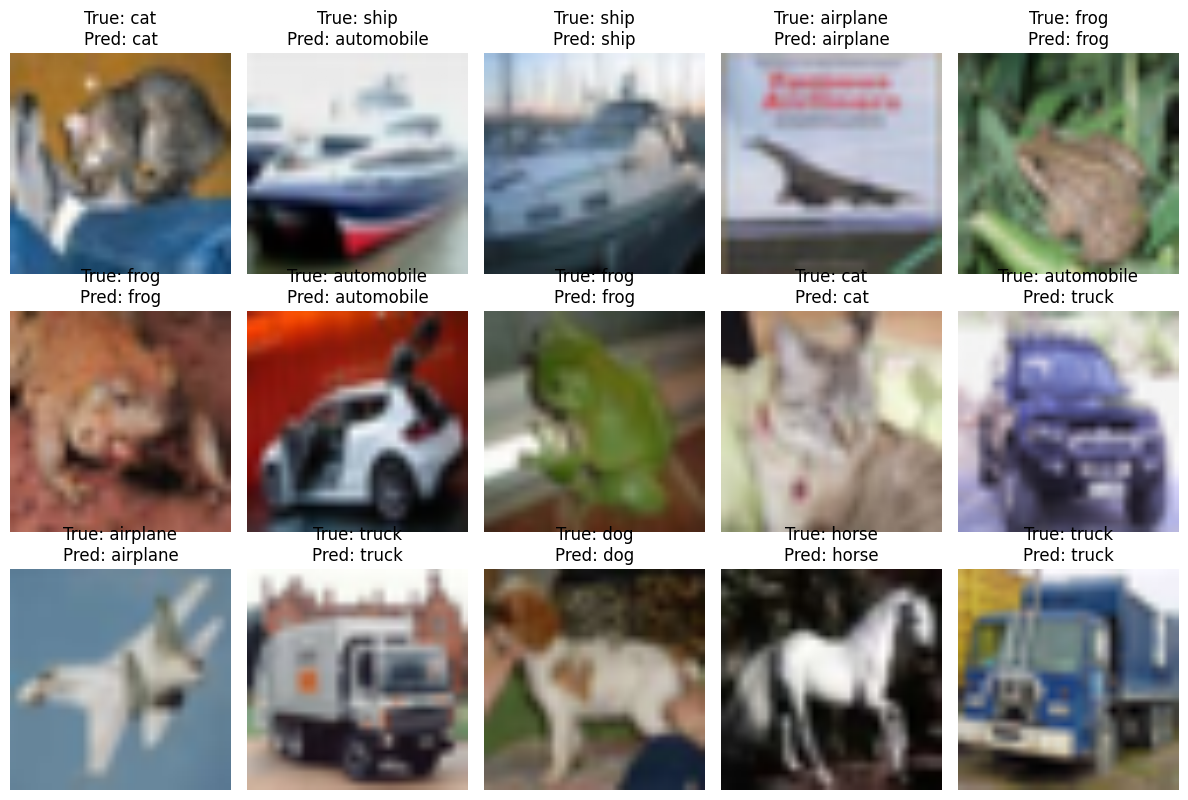


URUCHAMIAM: PartialFineTuning
Epoka 1/5 (LR: 0.00100) | Train Loss: 0.4507 Acc: 0.8458 | Val Loss: 0.3818 Acc: 0.8697
Epoka 2/5 (LR: 0.00100) | Train Loss: 0.2273 Acc: 0.9210 | Val Loss: 0.5474 Acc: 0.8165
Epoka 3/5 (LR: 0.00100) | Train Loss: 0.1310 Acc: 0.9539 | Val Loss: 0.4499 Acc: 0.8626
Epoka 4/5 (LR: 0.00100) | Train Loss: 0.0772 Acc: 0.9747 | Val Loss: 0.7888 Acc: 0.7738

Early Stopping! Brak poprawy od 3 epok.

Trening zakończony. Najlepszy model załadowany.
Predykcje dla PartialFineTuning:


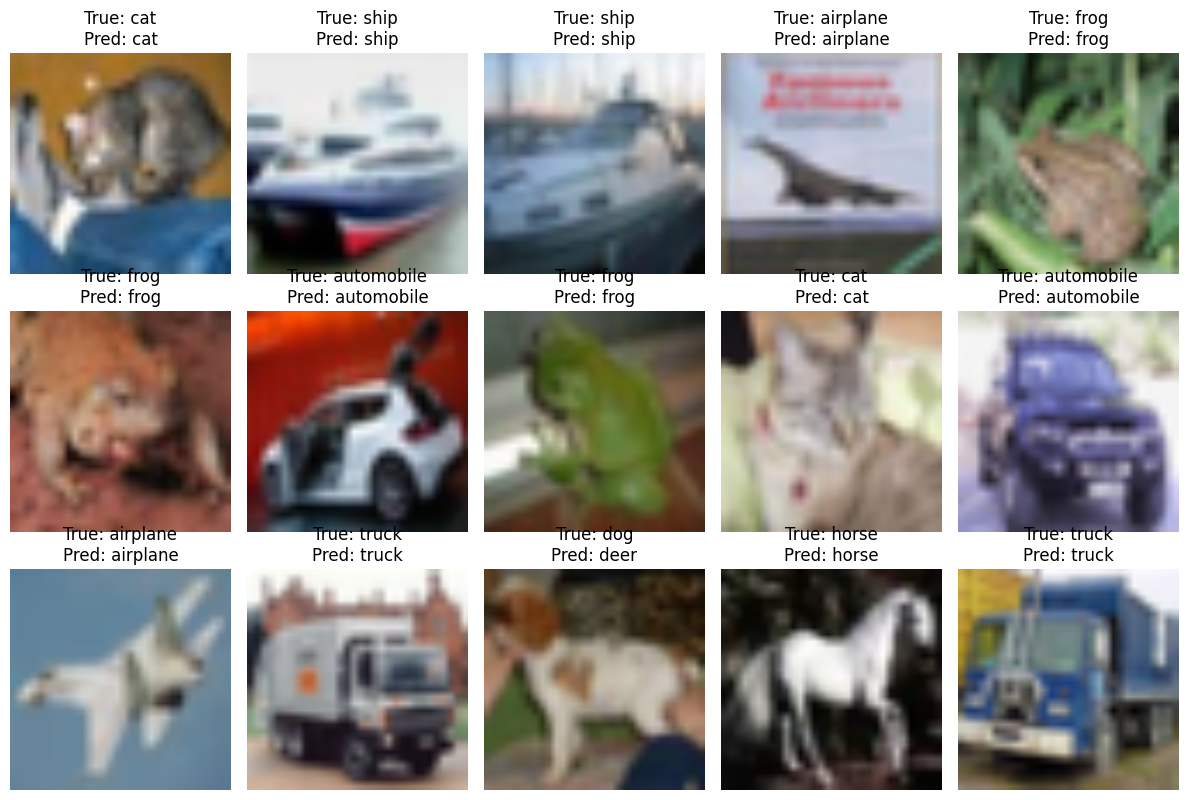


URUCHAMIAM: ullFineTuning
Epoka 1/5 (LR: 0.00100) | Train Loss: 0.4904 Acc: 0.8302 | Val Loss: 0.5478 Acc: 0.8282
Epoka 2/5 (LR: 0.00100) | Train Loss: 0.2693 Acc: 0.9075 | Val Loss: 0.4269 Acc: 0.8581
Epoka 3/5 (LR: 0.00100) | Train Loss: 0.1795 Acc: 0.9365 | Val Loss: 0.3060 Acc: 0.9017
Epoka 4/5 (LR: 0.00100) | Train Loss: 0.1220 Acc: 0.9578 | Val Loss: 0.3360 Acc: 0.8958
Epoka 5/5 (LR: 0.00100) | Train Loss: 0.0937 Acc: 0.9671 | Val Loss: 0.4038 Acc: 0.8792

Trening zakończony. Najlepszy model załadowany.
Predykcje dla ullFineTuning:


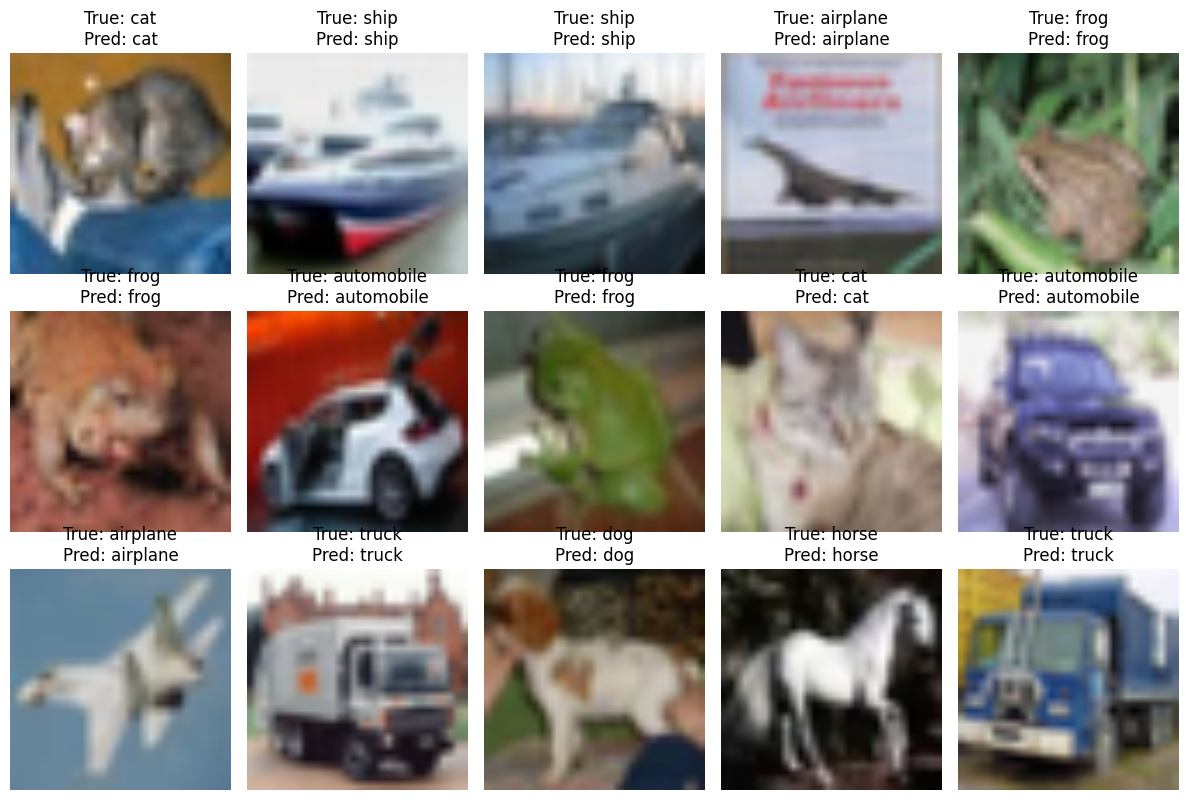


URUCHAMIAM: TrainingFromScratch
Epoka 1/5 (LR: 0.00100) | Train Loss: 1.4443 Acc: 0.4683 | Val Loss: 1.3390 Acc: 0.5300
Epoka 2/5 (LR: 0.00100) | Train Loss: 0.9522 Acc: 0.6609 | Val Loss: 1.0979 Acc: 0.6245
Epoka 3/5 (LR: 0.00100) | Train Loss: 0.7157 Acc: 0.7478 | Val Loss: 0.8496 Acc: 0.7103
Epoka 4/5 (LR: 0.00100) | Train Loss: 0.5632 Acc: 0.8034 | Val Loss: 0.7551 Acc: 0.7408
Epoka 5/5 (LR: 0.00100) | Train Loss: 0.4558 Acc: 0.8409 | Val Loss: 0.8821 Acc: 0.7247

Trening zakończony. Najlepszy model załadowany.
Predykcje dla TrainingFromScratch:


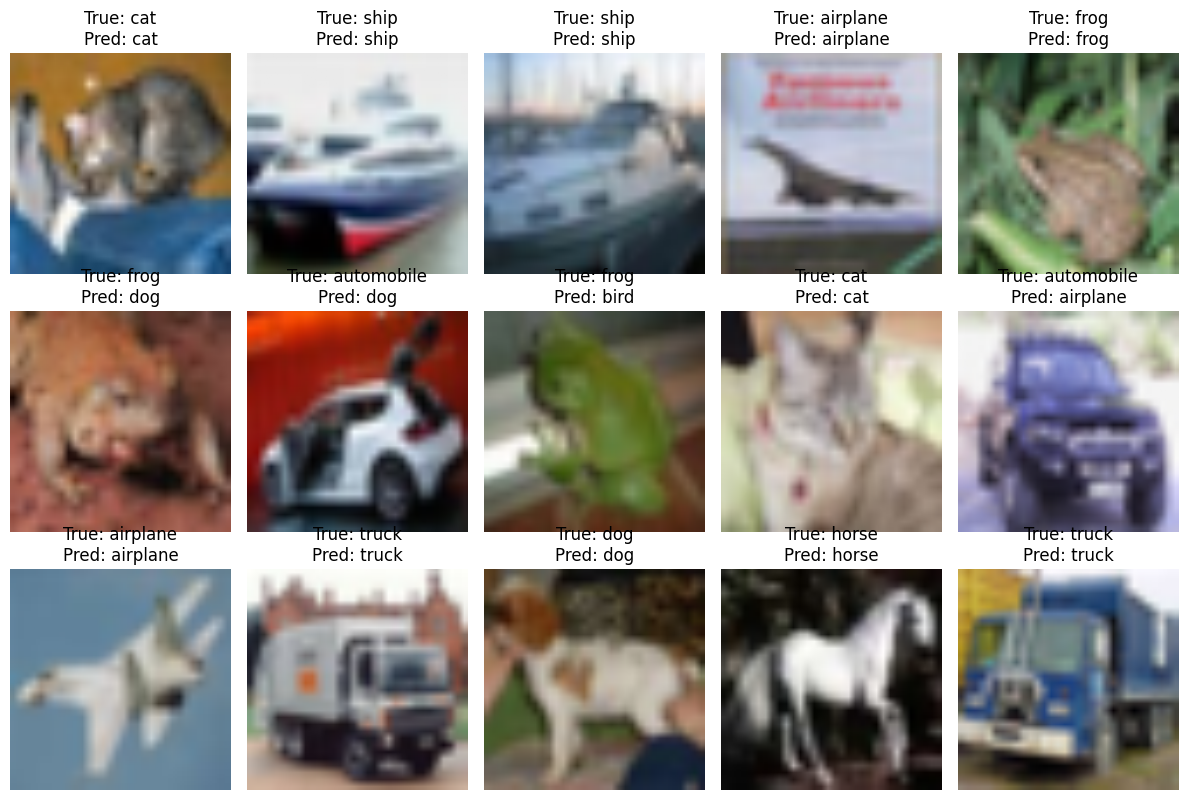


--- ZBIORCZE WYNIKI ---
LinearProbing: 76.01%
PartialFineTuning: 86.23%
ullFineTuning: 90.17%
TrainingFromScratch: 74.15%


In [27]:
results = {}
modes = [
    ("linear_probing", True, "LinearProbing"),
    ("partial_fine_tuning", True, "PartialFineTuning"),
    ("full_fine_tuning", True, "ullFineTuning"),
    ("scratch", False, "TrainingFromScratch")
]

for mode, is_pretrained, name in modes:
    print(f"\n{'='*30}\nURUCHAMIAM: {name}\n{'='*30}")


    model = get_resnet_for_exp(mode=mode, pretrained=is_pretrained)


    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=0.001)
    criterion = nn.CrossEntropyLoss()


    trainer = Trainer(model, optimizer, criterion, patience=3, seed=67)


    history = trainer.train(train_loader, val_loader, n_epochs=5, save_path=f"{name}.pth")

    print(f"Predykcje dla {name}:")
    trainer.predict(test_loader)


    acc = trainer.evaluate_test(test_loader)
    results[name] = acc


    del model, trainer
    torch.cuda.empty_cache()


print("\n--- ZBIORCZE WYNIKI ---")
for name, acc in results.items():
    print(f"{name}: {acc*100:.2f}%")

Wyniki to accuracy na danych testowych

1. model sobie najlepiej porawdzil dla full fine tuning
2. spodziewalam sie lepszych wynikow od resnetu na takich danych
3. niestety zapomnialam dac wykresy uczenia, a nie chce znowu czekac 25min 😢
4. model dosyc szybko robil overfitting

